In [2]:
!pip install lsd-lite

In [69]:
from scipy.ndimage import gaussian_filter, maximum_filter, label
from skimage.segmentation import watershed
import matplotlib.pyplot as plt
import numpy as np

In [70]:
def create_random_segmentation(size, seed):
    np.random.seed(seed)
    peaks = np.random.random(size).astype(np.float32)
    peaks = gaussian_filter(peaks, sigma=5.0)
    max_filtered = maximum_filter(peaks, 10)
    maxima = max_filtered == peaks
    seeds, n = label(maxima)
    print(f"Creating segmentation with {n} segments")
    return watershed(1.0 - peaks, seeds).astype(np.uint64)

In [71]:
#2d
segmentation = create_random_segmentation((64,)*2, seed=42)

Creating segmentation with 9 segments


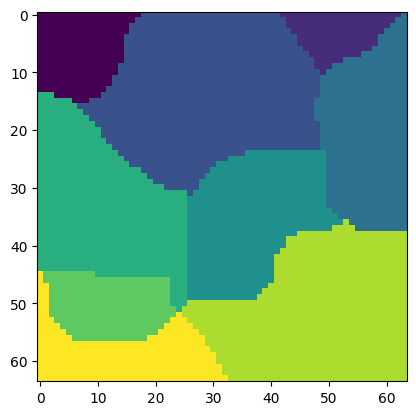

In [72]:
plt.imshow(segmentation)

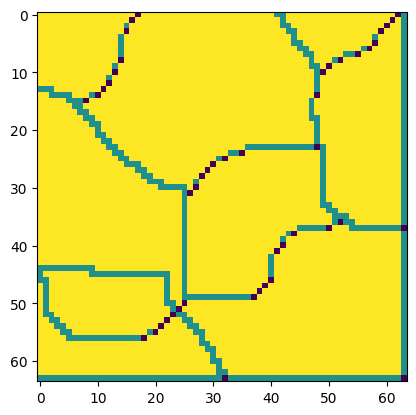

In [73]:
from lsd_lite import get_affs

affs = get_affs(segmentation, neighborhood=[[1,0],[0,1]])

plt.imshow(affs.mean(axis=0))

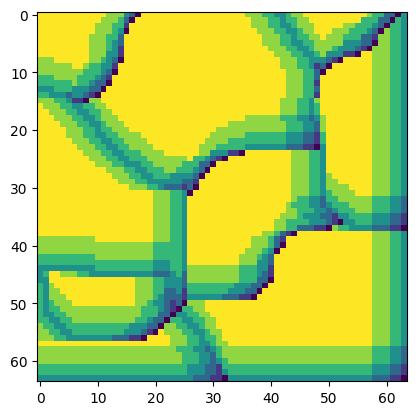

In [74]:
affs = get_affs(
    segmentation,
    neighborhood=[
      [1,0],
      [0,1],
      [3,0],
      [0,3],
      [6,0],
      [0,6]
    ]
)

plt.imshow(affs.mean(axis=0))

In [79]:
def view(data):
  fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(10, 7))
  axs = axs.ravel()
  for i, ax in enumerate(axs):
      ax.imshow(lsds[i])
      ax.set_title(f'Channel {i+1}')

  plt.tight_layout()
  plt.show()

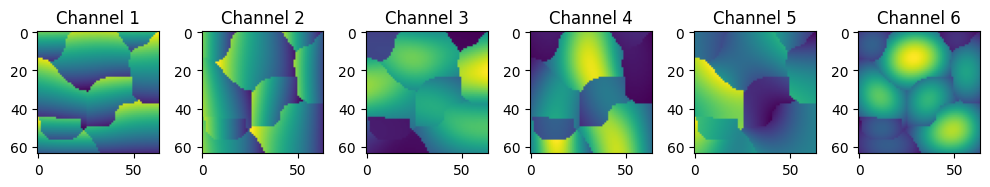

In [80]:
from lsd_lite import get_lsds

lsds = get_lsds(segmentation, sigma=10)

view(lsds)

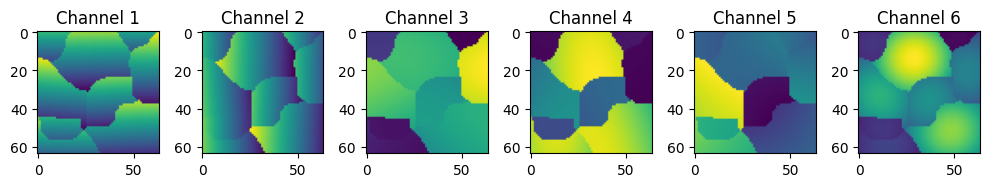

In [81]:
# larger sigma
lsds = get_lsds(segmentation, sigma=20)

view(lsds)

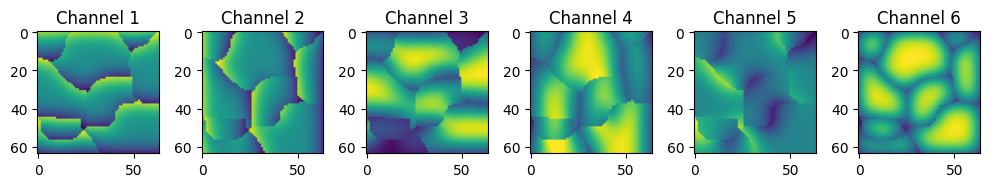

In [82]:
# smaller sigma
lsds = get_lsds(segmentation, sigma=5)

view(lsds)

Creating segmentation with 38 segments


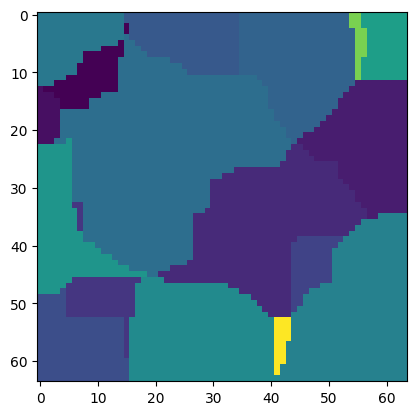

In [46]:
#3d
segmentation = create_random_segmentation((64,)*3, seed=42)

# view 10th section
plt.imshow(segmentation[10])

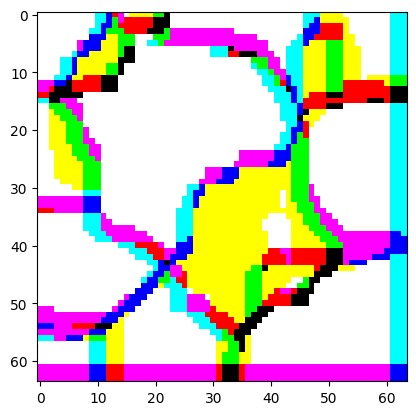

In [55]:
affs = get_affs(
    segmentation,
    neighborhood=[
      [1,0,0],
      [0,1,0],
      [3,0,0],
      [0,3,0],
      [0,0,3],
      [6,0,0],
      [0,6,0],
      [0,0,6]
    ]
)

# view mid range of section 10 in rgb
plt.imshow(affs[3:6, 10].T.astype(np.float32))

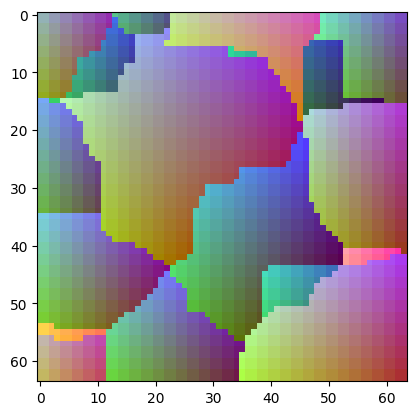

In [64]:
# add downsample
lsds = get_lsds(segmentation, sigma=10, downsample=2)

# view offsets in rgb
plt.imshow(lsds[0:3, 10].T)

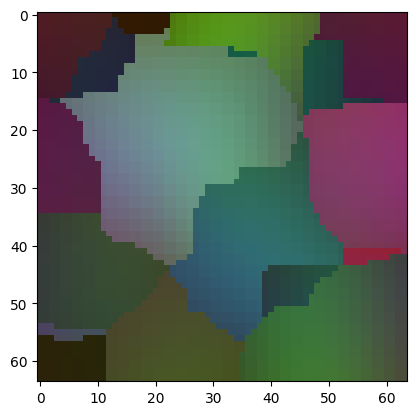

In [65]:
# view diagonals
plt.imshow(lsds[3:6, 10].T)

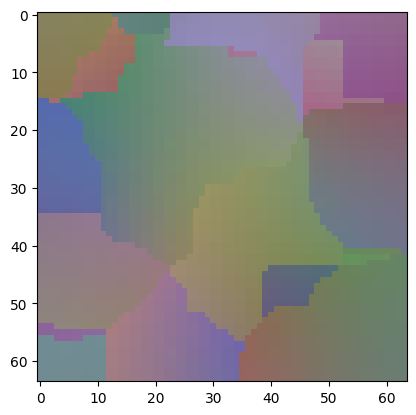

In [66]:
# view off-diagonals
plt.imshow(lsds[6:9, 10].T)

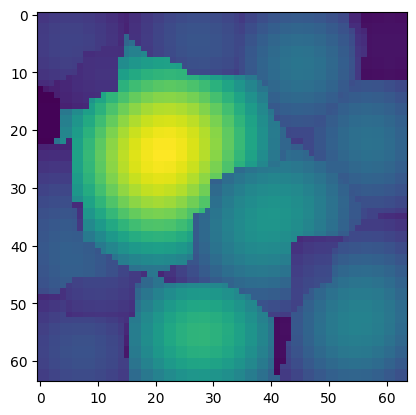

In [68]:
# view size
plt.imshow(lsds[9, 10])